# Brazilian E-Commerce Analytics Project

## Objective

This project analyzes the Brazilian E-Commerce Public Dataset by Olist.

The project demonstrates:

- Data ingestion using DuckDB
- Data modeling using dbt
- Data quality testing using dbt tests
- Exploratory and business analysis using Pandas
- Data visualization using Matplotlib

## Tools

- Python
- DuckDB
- dbt
- Pandas
- Matplotlib

## Connect to DuckDB

In [56]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

conn = duckdb.connect("../olist.db")

## Verify Star Schema

In [28]:
conn.sql("SHOW TABLES").df()

,name
0,category_translation
1,customers
2,dim_customer
3,dim_product
4,dim_seller
5,fact_sales
6,geolocation
7,order_items
8,orders
9,payments


The project follows a layered analytics engineering architecture consisting of raw source tables, dbt staging models, dimensional marts, and business analytics outputs.

### Raw Layer

customers<br>
orders<br>
order_items<br>
products<br>
sellers<br>
payments<br>
reviews<br>
geolocation<br>
category_translation

### Staging Layer

stg_orders<br>
stg_order_items

### Mart Layer

fact_sales<br>
dim_customer<br>
dim_product<br>
dim_seller

### Analytics Layer

Monthly Sales Trend<br>
Top Product Categories<br>
Revenue by State<br>
Customer RFM Analysis

## Monthly Revenue Trend

Analyze how revenue changed over time.

In [33]:
monthly_sales = conn.sql("""
SELECT
    date_trunc('month', purchase_date) AS sales_month,
    SUM(sales_amount) AS revenue
FROM fact_sales
GROUP BY 1
ORDER BY 1
""").df()

monthly_sales.head()

,sales_month,revenue
0,2016-09-01,354.75
1,2016-10-01,56808.84
2,2016-12-01,19.62
3,2017-01-01,137188.49
4,2017-02-01,286280.62


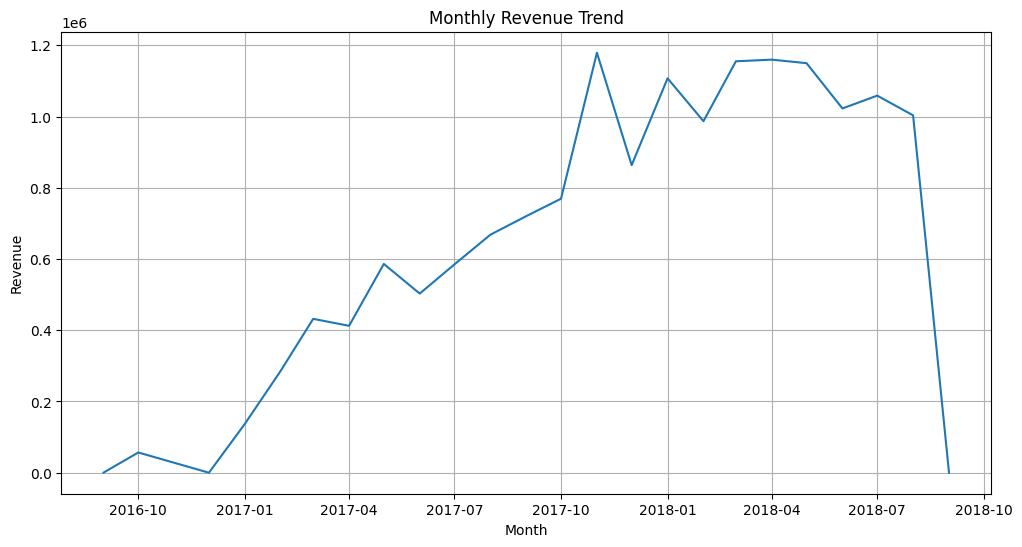

In [34]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["sales_month"],
    monthly_sales["revenue"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

### Insight

Revenue increased significantly during 2017–2018, indicating rapid platform growth.

## Top Product Categories

## Top Product Categories by Revenue

In [35]:
top_products = conn.sql("""
SELECT
    p.product_category_name,
    SUM(f.sales_amount) AS revenue
FROM fact_sales f
JOIN dim_product p
ON f.product_id = p.product_id
GROUP BY 1
ORDER BY revenue DESC
LIMIT 10
""").df()

top_products

,product_category_name,revenue
0,beleza_saude,1441248.07
1,relogios_presentes,1305541.61
2,cama_mesa_banho,1241681.72
3,esporte_lazer,1156656.48
4,informatica_acessorios,1059272.40
5,moveis_decoracao,902511.79
6,utilidades_domesticas,778397.77
7,cool_stuff,719329.95
8,automotivo,685384.32
9,ferramentas_jardim,584219.21


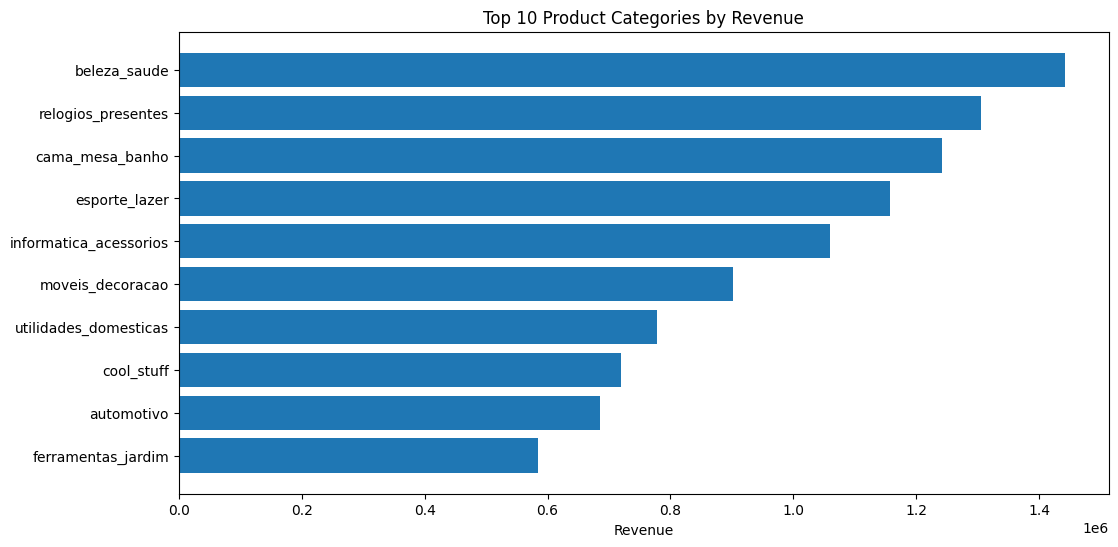

In [36]:
plt.figure(figsize=(12,6))

plt.barh(
    top_products["product_category_name"][::-1],
    top_products["revenue"][::-1]
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")

plt.show()

### Insight

Beauty & Health and Watches & Gifts generated the highest revenue.

## Revenue by State

In [37]:
revenue_by_state = conn.sql("""
SELECT
    c.customer_state,
    SUM(f.sales_amount) AS revenue
FROM fact_sales f
JOIN dim_customer c
ON f.customer_id = c.customer_id
GROUP BY 1
ORDER BY revenue DESC
""").df()

revenue_by_state.head(10)

,customer_state,revenue
0,SP,5921678.12
1,RJ,2129681.98
2,MG,1856161.49
3,RS,885826.76
4,PR,800935.44
5,BA,611506.67
6,SC,610213.60
7,DF,353229.44
8,GO,347706.93
9,ES,324801.91


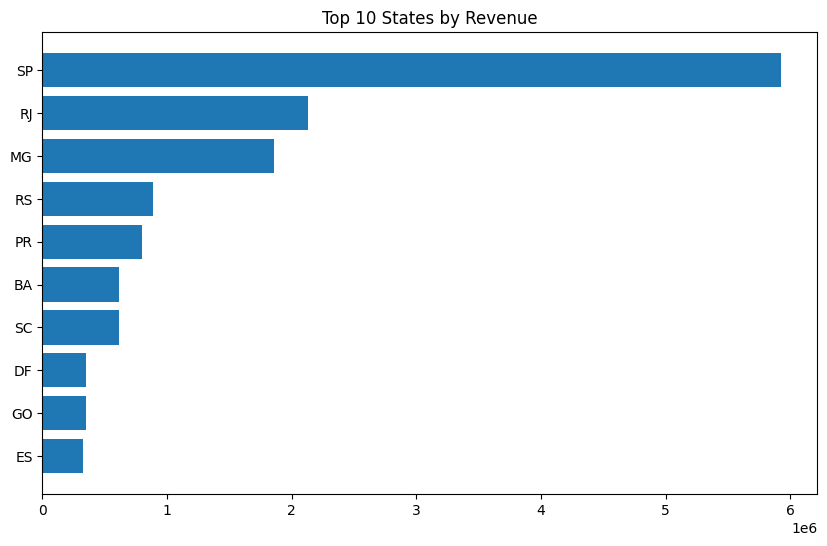

In [38]:
top_states = revenue_by_state.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_states["customer_state"][::-1],
    top_states["revenue"][::-1]
)

plt.title("Top 10 States by Revenue")

plt.show()

### Insight

São Paulo (SP) generated the highest revenue among all states.

## Customer RFM Analysis

Analyze customer purchasing behavior using:

- Recency
- Frequency
- Monetary Value

In [39]:
rfm = conn.sql("""
SELECT
    c.customer_unique_id,
    MAX(f.purchase_date) AS last_purchase,
    COUNT(DISTINCT f.order_id) AS frequency,
    SUM(f.sales_amount) AS monetary
FROM fact_sales f
JOIN dim_customer c
ON f.customer_id = c.customer_id
GROUP BY 1
ORDER BY frequency DESC
LIMIT 20
""").df()

rfm

,customer_unique_id,last_purchase,frequency,monetary
0,8d50f5eadf50201ccdcedfb9e2ac8455,2018-08-20,16,902.04
1,3e43e6105506432c953e165fb2acf44c,2018-02-27,9,1172.67
2,6469f99c1f9dfae7733b25662e7f1782,2018-06-28,7,758.83
3,1b6c7548a2a1f9037c1fd3ddfed95f33,2018-02-14,7,959.01
4,ca77025e7201e3b30c44b472ff346268,2018-06-01,7,1122.72
5,dc813062e0fc23409cd255f7f53c7074,2018-08-23,6,1033.62
6,12f5d6e1cbf93dafd9dcc19095df0b3d,2017-01-05,6,110.72
7,47c1a3033b8b77b3ab6e109eb4d5fdf3,2018-01-24,6,944.21
8,63cfc61cee11cbe306bff5857d00bfe4,2018-05-28,6,826.32
9,f0e310a6839dce9de1638e0fe5ab282a,2018-04-05,6,540.69


### Insight

Some customers made up to 16 purchases, demonstrating strong repeat buying behavior.

## Data Quality Validation

## Data Quality Validation

The data warehouse was validated using dbt tests to ensure data quality and integrity.

Tests performed:

- customer_id is unique
- customer_id is not null
- product_id is unique
- product_id is not null
- seller_id is unique
- seller_id is not null
- order_id is not null

### dbt Test Results

<img src="../images/dbt_test_results.png" width="800">

All 7 tests passed successfully.

## Data Warehouse Architecture

orders<br>
 &nbsp;&nbsp;&nbsp;↓<br>
stg_orders<br>
 &nbsp;&nbsp;&nbsp;↓<br>
fact_sales<br>
<br>
order_items<br>
 &nbsp;&nbsp;&nbsp;↓<br>
stg_order_items<br>
&nbsp;&nbsp;&nbsp;↓<br>
fact_sales

### dbt Test Results

<img src="../images/dbt_docs.png" width="800">

# Conclusion

This project successfully:

- Loaded raw CSV data into DuckDB
- Built a star schema using dbt
- Implemented data quality tests
- Generated business insights through analytics

Key Findings:

1. São Paulo generated the highest revenue.
2. Beauty & Health was the top product category.
3. Revenue grew substantially during 2017–2018.
4. Repeat customers contributed significantly to sales.